In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('sample_data/mnist_train_small.csv')

In [6]:
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Columns: 785 entries, 6 to 0.590
dtypes: int64(785)
memory usage: 119.8 MB


In [7]:
df.shape

(19999, 785)

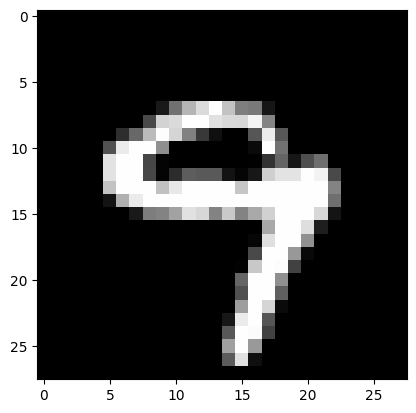

In [10]:
plt.imshow(df.iloc[2,1:].values.reshape(28,28), cmap='gray')

In [12]:
X = df.drop('6', axis=1)
y = df['6']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15999, 784), (4000, 784), (15999,), (4000,))

In [15]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.95525

# StandardScaler

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.9215

# Apply PCA

In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [21]:
knn = KNeighborsClassifier()
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
accuracy_score(y_test, y_pred)

0.94125

In [24]:
accuracy = []
for i in range(70, 150):
    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    knn = KNeighborsClassifier()
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    accuracy.append(accuracy_score(y_test,y_pred))


Text(0.5, 1.0, 'Accuracy vs Number of Components')

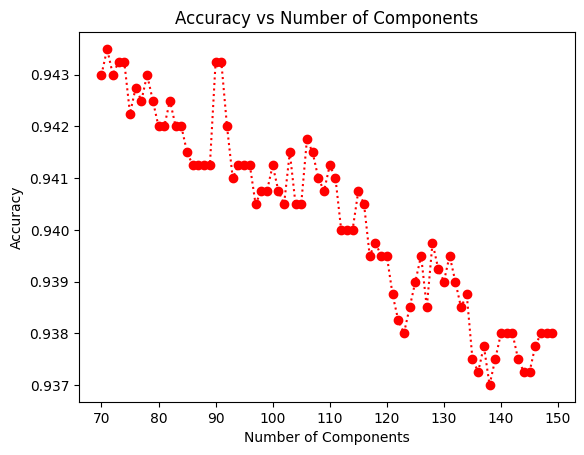

In [30]:
plt.plot(range(70,150), accuracy, 'o:r')
plt.xlabel('Number of Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Components')

# Visualization

In [31]:
# Transforming 2D coordinate system
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [32]:
X_train_pca

array([[-2.64388752,  1.82180386],
       [-3.97314247, -4.56300005],
       [-7.48361932, -1.33266029],
       ...,
       [ 2.02183629,  6.47553651],
       [ 8.21824316, 19.22591938],
       [ 4.87314199, 10.40539569]])

In [35]:
import plotly.express as px
# y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_pca[:,0], y=X_train_pca[:,1],
                 color=y_train, color_continuous_scale='rainbow')
fig.show()

In [36]:
# Transforming 3D coordinate system
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [37]:
X_train_pca

array([[ -2.64388752,   1.82180386,   3.92197665],
       [ -3.97314247,  -4.56300005,   1.64148137],
       [ -7.48361932,  -1.33266029,   3.17676199],
       ...,
       [  2.02183629,   6.47553651,   4.61065221],
       [  8.21824316,  19.22591938,   2.98975773],
       [  4.87314199,  10.40539569, -14.15792507]])

In [39]:
# y_train_trf = y_train.astype(str)
fig = px.scatter_3d(x=X_train_pca[:,0], y=X_train_pca[:,1], z=X_train_pca[:,2],
                 color=y_train, color_continuous_scale='rainbow')
fig.update_layout(margin=dict(l=20, r=20, b=20, t=20))
fig.show()

In [40]:
# Eigen Values
pca.explained_variance_

array([41.15287737, 29.74356311, 26.77529536])

In [42]:
# Eigen Vector
pca.components_.shape

(3, 784)

# Finding optimum number of PC

In [43]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [44]:
pca.explained_variance_.shape

(784,)

In [45]:
pca.components_.shape

(784, 784)

In [46]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05972468, 0.10289116, 0.14174983, 0.17207244, 0.19811419,
       0.22103136, 0.24133663, 0.25939057, 0.2753868 , 0.28992425,
       0.30396441, 0.31675046, 0.32863549, 0.3401442 , 0.35088116,
       0.36124566, 0.37107214, 0.38069355, 0.39000561, 0.39907306,
       0.40776135, 0.41625644, 0.42426632, 0.4321929 , 0.43991664,
       0.44736439, 0.45471364, 0.4616764 , 0.46841738, 0.47496064,
       0.48134429, 0.48761487, 0.49384031, 0.49986217, 0.50583386,
       0.51171684, 0.51755359, 0.52319067, 0.52862059, 0.53400856,
       0.53934216, 0.54455906, 0.54963495, 0.55457507, 0.5594546 ,
       0.56425033, 0.5689664 , 0.57360869, 0.57820769, 0.58269461,
       0.58716453, 0.59153193, 0.59586424, 0.60011701, 0.6042857 ,
       0.60834706, 0.61234004, 0.61627214, 0.62015944, 0.62398311,
       0.62776889, 0.63146562, 0.63511597, 0.63872827, 0.64232559,
       0.64587513, 0.64936355, 0.65275925, 0.65612997, 0.65947237,
       0.6627727 , 0.66605477, 0.66929108, 0.67247646, 0.67563

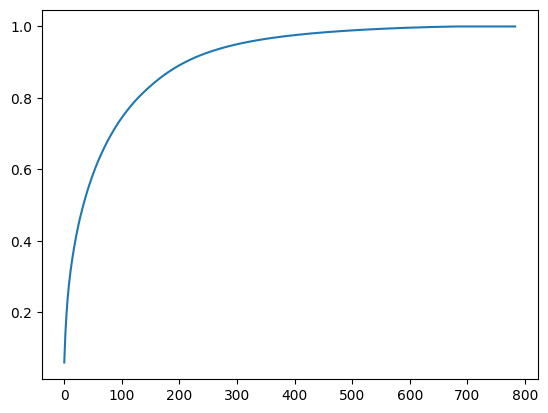

In [47]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))